# 02 - Baselines (rewired, corrected target)

Uses the shared modules `features.py`, `metrics.py`, and `targets.py`.
Baseline *logic* (vol-only, Ridge, XGBoost) is unchanged. What changed vs the
original 02:

- **Target** now built by `targets.build_targets` - 365-calendar-day forward
  window + full delisting rules. Fixes the `head(252)` no-cap bug that produced
  a ~52% base rate. Watch the `summarize_targets` output: large_dd_30 should
  land in ~10-20% (brief 2, 9.5), not ~50%.
- **Features** from `features.build_financial_matrix` - locked 18 ratios,
  train-fold-only scaling, (N,5,18) then flattened to (N,90).
- **Evaluation** from `metrics.evaluate` - within-year Spearman / top-decile.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression, RidgeCV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shared project modules (must be on the import path / repo root)
import features as F
import metrics as M

# >>> EACH TEAMMATE: point this at your local data folder <<<
DATA_DIR = Path('data')   # e.g. Path('/Users/you/.../MLII-Final/data')

TRAIN_YEARS = list(range(2003, 2018))   # 2003-2017
VAL_YEARS   = [2018, 2019]
TEST_YEARS  = list(range(2020, 2024))   # 2020-2023


In [2]:
print('Loading funda...')
funda = pd.read_parquet(DATA_DIR / 'compustat_funda.parquet')

print('Loading linktable...')
linktable = pd.read_parquet(DATA_DIR / 'crsp_linktable.parquet')

print('Loading bklabels...')
bklabels = pd.read_parquet(DATA_DIR / 'compustat_bklabels.parquet')

print('Loading dsf (price columns only)...')
dsf = pd.read_parquet(DATA_DIR / 'crsp_dsf.parquet',
                      columns=['permno','date','prc','ret','vol','cfacpr'])

print('Loading company...')
company = pd.read_parquet(DATA_DIR / 'compustat_company.parquet')

funda['fyear']         = funda['fyear'].astype(int)
funda['datadate']      = pd.to_datetime(funda['datadate'])
linktable['linkdt']    = pd.to_datetime(linktable['linkdt'])
linktable['linkenddt'] = pd.to_datetime(linktable['linkenddt'])
dsf['date']            = pd.to_datetime(dsf['date'])
dsf['prc']             = dsf['prc'].abs()

print(f'\nfunda: {funda.shape} | linktable: {linktable.shape} | dsf: {dsf.shape} | company: {company.shape}')


Loading funda...
Loading linktable...
Loading bklabels...
Loading dsf (price columns only)...
Loading company...

funda: (132447, 39) | linktable: (38738, 8) | dsf: (29203297, 6) | company: (45242, 20)


In [3]:
# Anchor = datadate + 90 days
anchors = (
    funda[['gvkey','fyear','datadate']]
    .query("fyear >= 2003 and fyear <= 2023")
    .dropna(subset=['datadate'])
    .copy()
)
anchors['anchor_date'] = anchors['datadate'] + pd.Timedelta(days=90)

# Resolve permno via linktable
anchors = anchors.merge(
    linktable[['gvkey','permno','linkdt','linkenddt']],
    on='gvkey', how='left'
)
anchors = anchors[
    (anchors['anchor_date'] >= anchors['linkdt']) &
    (anchors['anchor_date'] <= anchors['linkenddt'])
]
anchors = (anchors
           .sort_values(['gvkey','fyear','permno'])
           .drop_duplicates(subset=['gvkey','fyear'], keep='first')
           .drop(columns=['linkdt','linkenddt'])
           .reset_index(drop=True))

anchors['permno'] = anchors['permno'].astype(int)
print(f"Anchors with permno: {anchors.shape}")
print(anchors.head(3))

Anchors with permno: (89115, 5)
    gvkey  fyear   datadate anchor_date  permno
0  001004   2003 2004-05-31  2004-08-29   54594
1  001004   2004 2005-05-31  2005-08-29   54594
2  001004   2005 2006-05-31  2006-08-29   54594


In [4]:
# Trailing 12m realized volatility (needed for the vol-only baseline).
# The forward-drawdown TARGET is now built by targets.py in the next cell.
dsf_idx = dsf.set_index('permno')

def compute_trail_vol(permno, anchor_date):
    if permno not in dsf_idx.index:
        return np.nan
    firm = dsf_idx.loc[permno].sort_values('date')
    trail = firm[firm['date'] < anchor_date].tail(252)   # strictly before anchor
    rets = trail['ret'].dropna()
    if len(rets) < 20:
        return np.nan
    return rets.std() * np.sqrt(252)

print('Computing trailing volatility...')
anchors['trail_vol'] = [compute_trail_vol(r.permno, r.anchor_date) for r in anchors.itertuples()]
print(f"Vol NaN: {anchors['trail_vol'].isna().sum()}")



Computing trailing volatility...
Vol NaN: 554


In [5]:
import targets as T

# Build the forward 12-month drawdown target per brief 8.2:
#  - 365-CALENDAR-DAY window (fixes the head(252) no-cap bug -> ~52% base rate)
#  - full delisting rules (02/03/04 -> -1.0 ; 01/07 -> terminal, no forced loss)
anchors = T.build_targets(anchors, dsf, company)

# keep only anchors that also have a trailing-vol value (for the vol baseline)
anchors = anchors.dropna(subset=['trail_vol']).reset_index(drop=True)

T.summarize_targets(anchors)


Targets built: 87,294 anchors
  mean fwd_12m_max_dd : -0.374
  median              : -0.322
  large_dd_30 rate    : 54.1%   (brief expects ~10-20%)
  large_dd_50 rate    : 25.7%

  large_dd_30 rate by fyear:
fyear
2003    0.445
2004    0.382
2005    0.411
2006    0.676
2007    0.949
2008    0.484
2009    0.461
2010    0.669
2011    0.357
2012    0.273
2013    0.391
2014    0.616
2015    0.350
2016    0.363
2017    0.612
2018    0.873
2019    0.567
2020    0.585
2021    0.748
2022    0.582
2023    0.511


## Financial features via `features.py`
Replaces the old inline ratio/winsorize/flatten cells. Scaler is fit on the
**train fold only**.

In [6]:
# 1. Compute the locked 18 ratios on the full funda panel
ratios_full = F.compute_ratios(funda)[['gvkey','fyear'] + F.RATIO_COLS].copy()

# 2. Fit the winsorize+z-score scaler on TRAIN-FOLD rows only, then transform all
ratio_train_mask = ratios_full['fyear'].isin(TRAIN_YEARS).to_numpy()
scaler = F.FinancialFeatureScaler().fit(ratios_full, ratio_train_mask)
scaled_ratios = scaler.transform(ratios_full)

# 3. Build the (N,5,18) matrix aligned to the anchor panel
X_fin_3d, valid_fin = F.build_financial_matrix(anchors, scaled_ratios, require_full_window=True)
print(f'Financial matrix: {X_fin_3d.shape} | anchors with full 5y window: {valid_fin.sum():,}/{len(valid_fin):,}')

# Keep only anchors with a complete financial window (drops the rest from everything)
anchors = anchors[valid_fin].reset_index(drop=True)
X_fin_3d = X_fin_3d[valid_fin]

# Flattened (N,90) view for the baselines
X_fin_flat = F.flatten_for_baselines(X_fin_3d)
print(f'Flattened financial: {X_fin_flat.shape}')


Financial matrix: (87294, 5, 18) | anchors with full 5y window: 76,912/87,294
Flattened financial: (76912, 90)


## Price features (unchanged logic from original cells 9-10)

In [7]:
# 7 price features per anchor from 252 trading days before anchor_date
# 1. Annualized volatility
# 2. Total return
# 3. Skewness of daily returns
# 4. Kurtosis of daily returns
# 5. Max prior 12-month drawdown
# 6. Beta vs equal-weighted market
# 7. Log average daily dollar volume

from scipy.stats import skew, kurtosis

# Precompute equal-weighted market returns per day
market_ret = (dsf.groupby('date')['ret']
              .mean()
              .rename('mkt_ret')
              .reset_index())
market_ret_idx = market_ret.set_index('date')['mkt_ret']

# Index dsf for fast lookup (already done but reset here cleanly)
dsf['dollar_vol'] = dsf['prc'].abs() * dsf['vol']
dsf_price_idx = dsf.set_index('permno')

def compute_price_features(permno, anchor_date):
    if permno not in dsf_price_idx.index:
        return [np.nan] * 7

    firm = dsf_price_idx.loc[permno].sort_values('date')
    trail = firm[firm['date'] < anchor_date].tail(252)

    if len(trail) < 60:
        return [np.nan] * 7

    rets = trail['ret'].dropna()
    if len(rets) < 60:
        return [np.nan] * 7

    # 1. Annualized volatility
    vol_ann = rets.std() * np.sqrt(252)

    # 2. Total return
    total_ret = (1 + rets).prod() - 1

    # 3. Skewness
    ret_skew = skew(rets)

    # 4. Kurtosis
    ret_kurt = kurtosis(rets)

    # 5. Max prior drawdown
    adj = (trail['prc'].abs() / trail['cfacpr'].replace(0, np.nan)).dropna()
    if len(adj) < 20:
        max_dd = np.nan
    else:
        roll_max = adj.cummax()
        max_dd = ((adj - roll_max) / roll_max).min()

    # 6. Beta vs equal-weighted market
    mkt = market_ret_idx.reindex(trail['date'].values).dropna()
    firm_rets = trail.set_index('date')['ret'].reindex(mkt.index).dropna()
    mkt = mkt.reindex(firm_rets.index)
    if len(firm_rets) < 30:
        beta = np.nan
    else:
        cov = np.cov(firm_rets.values, mkt.values)
        beta = cov[0, 1] / (cov[1, 1] + 1e-10)

    # 7. Log average daily dollar volume
    log_dv = np.log(trail['dollar_vol'].replace(0, np.nan).mean() + 1e-6)

    return [vol_ann, total_ret, ret_skew, ret_kurt, max_dd, beta, log_dv]

print("Computing 7 price features (few minutes)...")
price_features = np.array([
    compute_price_features(row.permno, row.anchor_date)
    for row in anchors.itertuples()
])

PRICE_COLS = ['pf_vol', 'pf_ret', 'pf_skew', 'pf_kurt',
              'pf_max_dd', 'pf_beta', 'pf_log_dv']

print(f"Price features shape: {price_features.shape}")
print(f"NaN per feature: {np.isnan(price_features).sum(axis=0)}")

Computing 7 price features (few minutes)...
Price features shape: (76912, 7)
NaN per feature: [ 99  99  99  99 107  99  99]


In [8]:
# Z-score price features within fyear using train fold only
price_df = pd.DataFrame(price_features, columns=PRICE_COLS)
price_df['fyear'] = anchors['fyear'].values

# Compute train-fold means and stds per fyear
train_mask_temp = np.isin(anchors['fyear'].values, TRAIN_YEARS)

price_stats = (price_df[train_mask_temp]
               .groupby('fyear')[PRICE_COLS]
               .agg(['mean','std']))

def zscore_price(df):
    out = df.copy()
    for col in PRICE_COLS:
        yr = df['fyear']
        means = yr.map(price_stats[col]['mean'])
        stds  = yr.map(price_stats[col]['std'])
        out[col] = (df[col] - means) / (stds + 1e-8)
    return out

price_df_scaled = zscore_price(price_df)

# Fill NaN with 0 (z-score mean)
price_df_scaled[PRICE_COLS] = price_df_scaled[PRICE_COLS].fillna(0)

# Concatenate with financial features → 97-wide matrix
X_full = np.concatenate([X_fin_flat, price_df_scaled[PRICE_COLS].values], axis=1)
all_cols = F.flat_feature_names() + PRICE_COLS

print(f"Final feature matrix: {X_full.shape}")
print(f"Expected: ({len(anchors)}, 97)")
print(f"Any NaN: {np.isnan(X_full).any()}")

Final feature matrix: (76912, 97)
Expected: (76912, 97)
Any NaN: False


## Time-blocked split (carries `yrs` through for within-year metrics)

In [9]:
X     = X_full
y     = anchors['fwd_12m_max_dd'].values
vol   = anchors['trail_vol'].values
yrs   = anchors['fyear'].values

train_mask = np.isin(yrs, TRAIN_YEARS)
val_mask   = np.isin(yrs, VAL_YEARS)
test_mask  = np.isin(yrs, TEST_YEARS)

X_train, y_train, vol_train, yrs_train = X[train_mask], y[train_mask], vol[train_mask], yrs[train_mask]
X_val,   y_val,   vol_val,   yrs_val   = X[val_mask],   y[val_mask],   vol[val_mask],   yrs[val_mask]
X_test,  y_test,  vol_test,  yrs_test  = X[test_mask],  y[test_mask],  vol[test_mask],  yrs[test_mask]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Test base rate (dd <= -30%): {(y_test <= -0.30).mean():.1%}')


Train: (54386, 97) | Val: (7201, 97) | Test: (15325, 97)
Test base rate (dd <= -30%): 55.3%


## Baseline 0 — Volatility only

In [10]:
vol_model = LinearRegression().fit(vol_train.reshape(-1,1), y_train)
print(f'drawdown = {vol_model.coef_[0]:.4f} * vol + {vol_model.intercept_:.4f}')
y_pred_vol_test = vol_model.predict(vol_test.reshape(-1,1))

results = []
results.append(M.evaluate('Baseline 0 - Vol Only', y_test, y_pred_vol_test, yrs_test))


drawdown = -0.2398 * vol + -0.2368

  Baseline 0 - Vol Only
  MAE                       : 0.1406
  RMSE                      : 0.1822
  R^2                       : 0.2444
  PR-AUC  (@ -30%)          : 0.8284
  ROC-AUC (@ -30%)          : 0.7850
  Recall @ 5% FPR           : 0.3813
  Brier                     : 0.4939
  Spearman  (within-year)   : 0.6357
  Top-decile prec (w/ year) : 0.4300
  (base rate @ -30%         : 0.553)


## Baseline 1 — Ridge

In [11]:
ridge = RidgeCV(alphas=[0.01,0.1,1.0,10.0,100.0,1000.0], scoring='neg_mean_absolute_error')
ridge.fit(X_train, y_train)
print(f'Best alpha: {ridge.alpha_}')
y_pred_ridge_test = ridge.predict(X_test)
results.append(M.evaluate('Baseline 1 - Ridge', y_test, y_pred_ridge_test, yrs_test))


Best alpha: 10.0

  Baseline 1 - Ridge
  MAE                       : 0.1459
  RMSE                      : 0.1877
  R^2                       : 0.1982
  PR-AUC  (@ -30%)          : 0.8107
  ROC-AUC (@ -30%)          : 0.7572
  Recall @ 5% FPR           : 0.3523
  Brier                     : 0.3222
  Spearman  (within-year)   : 0.5340
  Top-decile prec (w/ year) : 0.4278
  (base rate @ -30%         : 0.553)


## Baseline 2 — XGBoost

In [12]:
param_grid = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8},
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8},
    {'max_depth': 3, 'learning_rate': 0.10, 'n_estimators': 100, 'subsample': 0.8},
    {'max_depth': 4, 'learning_rate': 0.10, 'n_estimators': 100, 'subsample': 0.8},
]
from sklearn.metrics import mean_absolute_error
best_model, best_mae, best_params = None, np.inf, None
for params in param_grid:
    m = xgb.XGBRegressor(**params, random_state=42, verbosity=0)
    m.fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    print(f'  {params}  Val MAE={mae:.4f}')
    if mae < best_mae:
        best_mae, best_model, best_params = mae, m, params
print(f'\nBest params: {best_params}')
y_pred_xgb_test = best_model.predict(X_test)
results.append(M.evaluate('Baseline 2 - XGBoost', y_test, y_pred_xgb_test, yrs_test))


  {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8}  Val MAE=0.1742
  {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.8}  Val MAE=0.1724
  {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}  Val MAE=0.1728
  {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}  Val MAE=0.1718

Best params: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}

  Baseline 2 - XGBoost
  MAE                       : 0.1479
  RMSE                      : 0.1873
  R^2                       : 0.2018
  PR-AUC  (@ -30%)          : 0.8051
  ROC-AUC (@ -30%)          : 0.7458
  Recall @ 5% FPR           : 0.3502
  Brier                     : 0.2134
  Spearman  (within-year)   : 0.5344
  Top-decile prec (w/ year) : 0.4400
  (base rate @ -30%         : 0.553)


## Results table + feature importance


=== TEST SET RESULTS (corrected, within-year rank metrics) ===
                          mae    rmse      r2  pr_auc  roc_auc  recall_at_5fpr   brier  spearman_within_year  top_decile_prec_within_year
model                                                                                                                                    
Baseline 0 - Vol Only  0.1406  0.1822  0.2444  0.8284   0.7850          0.3813  0.4939                0.6357                       0.4300
Baseline 1 - Ridge     0.1459  0.1877  0.1982  0.8107   0.7572          0.3523  0.3222                0.5340                       0.4278
Baseline 2 - XGBoost   0.1479  0.1873  0.2018  0.8051   0.7458          0.3502  0.2134                0.5344                       0.4400


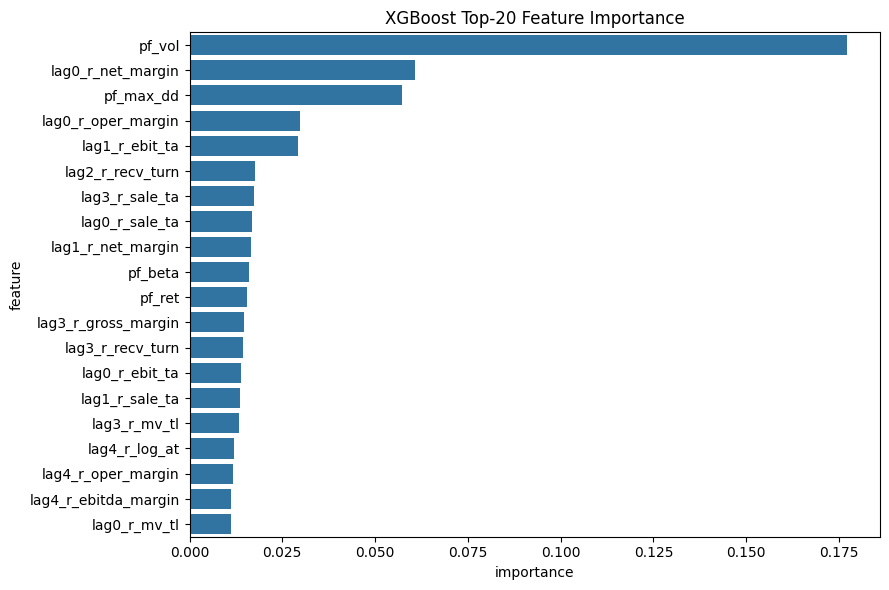

In [13]:
summary = M.results_table(results)
print('\n=== TEST SET RESULTS (corrected, within-year rank metrics) ===')
print(summary.round(4).to_string())

# Feature importance uses the shared flat names so labels are correct
importances = best_model.feature_importances_
feat_df = (pd.DataFrame({'feature': all_cols, 'importance': importances})
           .sort_values('importance', ascending=False).head(20))
plt.figure(figsize=(9,6))
sns.barplot(data=feat_df, x='importance', y='feature')
plt.title('XGBoost Top-20 Feature Importance')
plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importance.png', dpi=150)
plt.show()


## Save outputs

In [14]:
summary.to_csv(DATA_DIR / 'baseline_results.csv')

# Per-year Spearman for the writeup (shows the macro vs firm-level story)
for r in results:
    print(r['model'], '| within-year Spearman:', round(r['spearman_within_year'], 4),
          '| by year:', {k: round(v,3) for k,v in r['spearman_by_year'].items()})

print('\nSaved baseline_results.csv')


Baseline 0 - Vol Only | within-year Spearman: 0.6357 | by year: {2020: 0.545, 2021: 0.637, 2022: 0.666, 2023: 0.695}
Baseline 1 - Ridge | within-year Spearman: 0.534 | by year: {2020: 0.558, 2021: 0.48, 2022: 0.546, 2023: 0.552}
Baseline 2 - XGBoost | within-year Spearman: 0.5344 | by year: {2020: 0.593, 2021: 0.5, 2022: 0.511, 2023: 0.534}

Saved baseline_results.csv
